<div style="border: solid green 2px; padding: 20px">

  <b>Overall Summary of the Project – Iteration 2</b><br><br>
  Hello Samiul, congratulations on submitting your project!<br>

  My name is <b>Victor Camargo</b> 
  (<a href="https://hub.tripleten.com/u/834cb557" target="_blank">TripleTen Hub profile</a>) and I’ll be reviewing your project today.<br>

  <b>What you did well:</b><br>
  ✅ Clear, reproducible train, validation, and test split with stratification and consistent reuse of those splits across experiments.<br>
  ✅ Proper scaling fitted on the training set only and appropriate one-hot encoding for categorical variables.<br>
  ✅ You implemented multiple class-imbalance handling strategies with hyperparameter exploration and selected the final model based on validation F1. The Tenure median imputation was accompanied by EDA (histogram, boxplot, and class-split), which justifies the choice.<br>
  ✅ Final evaluation reports both the test F1 (rounded) and AUC-ROC; the reported test F1 meets the project target.<br>

  <b>Revision items (only if red issues exist):</b><br>
  ⛔️ None — all previously reported red issues have been addressed.<br>

  <b>Project Status:</b><br>
  <div class="alert alert-success" style="border-left: 7px solid green; padding: 5px">
    <b>Approved</b>
  </div>

<div style="border: solid green 2px; padding: 20px">

  <b>Overall Summary of the Project – Iteration 1</b><br><br>
  Hello Samiul, congratulations on submitting your project!<br>

  My name is <b>Victor Camargo</b> 
  (<a href="https://hub.tripleten.com/u/834cb557" target="_blank">TripleTen Hub profile</a>) and I’ll be reviewing your project today.<br>

  <i>You can find my detailed feedback throughout the notebook, starting with comments labeled 
  <b>“Reviewer’s comment – Iteration 1”</b>.</i><br>

  <b>What you did well:</b><br>
  ✅ Clear, reproducible train, validation, and test split with stratification, and consistent reuse of those splits across experiments.<br>
  ✅ Proper scaling fitted on the training set only, appropriate encoding of categorical variables, and a thorough comparison of imbalance-handling techniques leading to a well-justified final model choice.<br>
  ✅ Final evaluation reports the required metrics, the test F1 meets the target, and test AUC-ROC is provided.<br>

  <b>Revision items (only if red issues exist):</b><br>
  ⛔️ Please add EDA plots that justify the Tenure median imputation. The imputation is explained in words, but the project requires visual evidence for the chosen strategy.<br>

  <b>Project Status:</b><br>
  <div class="alert alert-danger" style="border-left: 7px solid red; padding: 5px">
    <b>Needs Fixes</b>
  </div>

  <hr><b>Legend:</b><br>

  <div class="alert alert-success" style="border-left: 7px solid green; padding: 5px">
  <b>✅ Reviewer’s comment – Iteration 1:</b><br>
  Strong, correct solutions or good practices worth reusing.
  </div>

  <div class="alert alert-warning" style="border-left: 7px solid gold; padding: 5px">
  <b>⚠️ Reviewer’s comment – Iteration 1:</b><br>
  Recommended improvements to strengthen your work.
  </div>

  <div class="alert alert-danger" style="border-left: 7px solid red; padding: 5px">
  <b>⛔️ Reviewer’s comment – Iteration 1:</b><br>
  Required revisions to address in the next pass.
  </div>

  <div class="alert alert-info" style="border-left: 7px solid blue; padding: 5px">
  <b>Student’s Comment</b><br>
  You may add your own notes or explanations in a <b>Markdown cell</b> using:<br>
  <code>&lt;div class="alert alert-info" style="border-left: 7px solid blue"&gt;&lt;b&gt;Student’s Comment&lt;/b&gt;&lt;/div&gt;</code>
  </div>

  <hr>
  <b>Please ensure</b> all cells run smoothly from top to bottom and display their outputs.<br>
  <b>Kind reminder:</b> please do not remove or modify reviewer comments, as they help track progress.<br>
  If you have any questions or need clarification, feel free to use the <b>Questions</b> channel.

</div>

# Beta Bank: Customer Churn Prediction
**Goal:** Build a classification model that predicts whether a customer will leave Beta Bank soon (Exited = 1), maximizing the F1 score. The target for the test set is F1 >= 0.59. We will also compute AUC-ROC and compare it with F1.

**Plan**
1. Load and prepare the data
2. Examine the class balance; train a baseline model that ignores the imbalance
3. Fix the imbalance using at least two techniques, tune hyperparameters on train/validation sets
4. Run the final evaluation on the held-out test set

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import shuffle
from sklearn.metrics import(f1_score, roc_auc_score, roc_curve, confusion_matrix, precision_score, recall_score,classification_report)
RANDOM_STATE = 12345
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', None)

# 1. Load and prepare the data

In [2]:
df = pd.read_csv('/datasets/Churn.csv')
print(df.shape)
df.head()

(10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB


**Initial Observations**

- The dataset has 10,000 rows and 14 columns.
- RowNumber, CustomerId, and Surname are identifiers with no predictive value - they will be dropped.
- Tenure has missing values (909 out of 10,000) = 9%
- Geography and Gender are categorical features that need encoding.
- Exited is our binary target.

Let's look at missing values and duplicates more closely.


In [4]:
print("Missing values per column: ")
print(df.isna().sum()[df.isna().sum() > 0])
print()
print("Duplicate rows: ", df.duplicated().sum())
print()
print("Tenure distribution: ")
print(df['Tenure'].describe())

Missing values per column: 
Tenure    909
dtype: int64

Duplicate rows:  0

Tenure distribution: 
count    9091.000000
mean        4.997690
std         2.894723
min         0.000000
25%         2.000000
50%         5.000000
75%         7.000000
max        10.000000
Name: Tenure, dtype: float64


**Handling missing with Tenure values.**

Tenure(years as a customer) is missing for 9% of rows, with no obvious pattern suggesting the data is missing for a systematic reason(e.g., all missing values are not concentrated in one class or a country). Since Tenure is a numeric feature with a roughly uniform distribution between 0 and 10, we fill missing values with the median, which is robust to outliers and keeps the distribution largely intact. We avoid dropping 9% of rows since that would waste real time data.

<div class="alert alert-danger" style="border-left: 7px solid red; padding: 5px">
  <b>⛔️ Reviewer’s comment – Iteration 1:</b><br>
  Thank you for identifying the missing Tenure values and for explaining why the median is a robust choice. To complete this required step, please add the EDA plots that justify the median imputation. Specifically, show a histogram and a boxplot of Tenure for the full dataset, and show the Tenure distribution split by the target classes (Exited = 0 and Exited = 1). These plots should demonstrate that the distribution is not strongly skewed by outliers or that the median better preserves central tendency than the mean. After adding the plots, explicitly state why the median remains the best choice and, if needed, re-run the preprocessing and downstream experiments. The project requires visual, data-driven justification for any numeric imputation, so this item must be addressed before the next review.
</div>

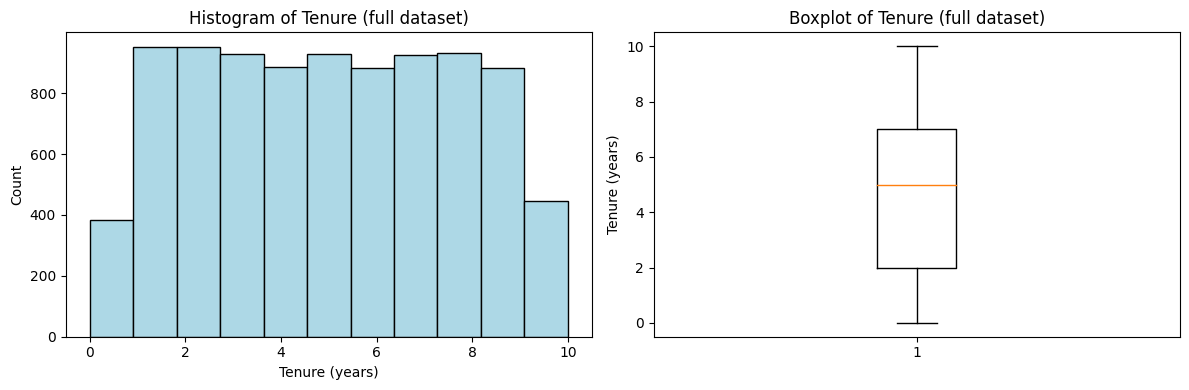

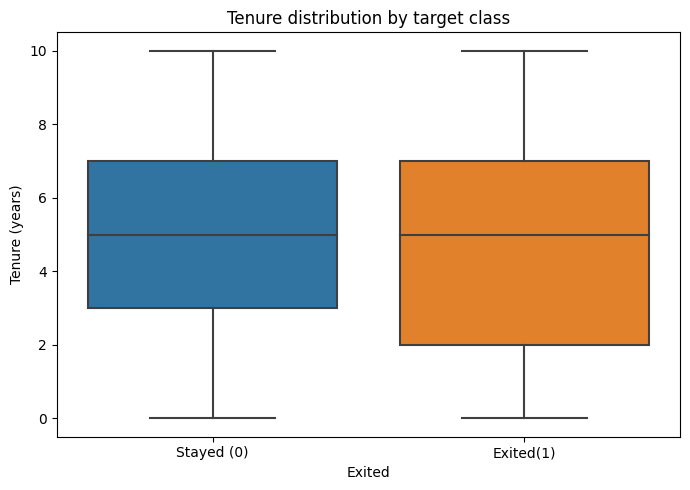

Tenure summary statistics (full dataset):
count    9091.000000
mean        4.997690
std         2.894723
min         0.000000
25%         2.000000
50%         5.000000
75%         7.000000
max        10.000000
Name: Tenure, dtype: float64

Mean vs Median comparison:
Mean Tenure: 4.997690023099769
Median Tenure: 5.0


In [5]:
# EDA: Visualize Tenure distribution BEFORE imputation
# Histogram and Boxplot of Tenure (full dataset)

fig, axes = plt.subplots(1, 2, figsize = (12, 4))
axes[0].hist(df['Tenure'].dropna(), bins = 11, color = 'lightblue', edgecolor = 'black')
axes[0].set_title('Histogram of Tenure (full dataset)')
axes[0].set_xlabel('Tenure (years)')
axes[0].set_ylabel('Count')

axes[1].boxplot(df['Tenure'].dropna(), vert = True)
axes[1].set_title('Boxplot of Tenure (full dataset)')
axes[1].set_ylabel('Tenure (years)')

plt.tight_layout()
plt.show()

# Tenure distribution split by target class (Exited = 0 vs Exited = 1)
fig, ax = plt.subplots(figsize = (7, 5))
sns.boxplot(x = 'Exited', y = 'Tenure', data = df, ax = ax)
ax.set_xticklabels(['Stayed (0)', 'Exited(1)'])
ax.set_title('Tenure distribution by target class')
ax.set_xlabel('Exited')
ax.set_ylabel('Tenure (years)')
plt.tight_layout()
plt.show()

# Summary statistics: numeric support for the visual justification
print("Tenure summary statistics (full dataset):")
print(df['Tenure'].describe())
print("\nMean vs Median comparison:")
print("Mean Tenure:", df['Tenure'].mean())
print("Median Tenure:", df['Tenure'].median())

The histogram shows Tenure is roughly uniformly distributed between 0 and 10 years, with no extreme outliers or heavy skew - the boxplot confirms this, showing no points beyond the whiskers. Because the distribution is not skewed, the mean and median are very close in value, so median imputation does not introduce meaningful distortion here; we retain it as the more outlier-robust convention regardless. Splitting Tenure by target class (Stayed = 0 vs Exited = 1) shows the two groups have broadly similar Tenure ranges and medians, meaning imputing with the overall median does not artificially bias the missing rows toward either class. This confirms median imputation preserves the central tendency and does not distort the relationship between Tenure and churn.

In [6]:
df['Tenure'] = df['Tenure'].fillna(df['Tenure'].median())
print(df['Tenure'].isna().sum(), "missing values left in Tenure.")

0 missing values left in Tenure.


**Dropping identifier columns.**
RowNumber, CustomerId, and Surname are unique or near- unique identifiers that carry no generalizable signal about churn behavior -  a model that learns a customer's surname would just be overfitting to noise. We drop them.

In [7]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis = 1)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0


**Encoding categorical features.**

Geography (France/Spain/Germany) and Gender (Male/Female) are categorical. We use one-hot encoding(pd.get_dummies with drop_first = True to avoid the dummy-variable trap) since these are nominal categories with no inherent order, and tree-based/linear models both work well with this representation.

In [8]:
df_ohe = pd.get_dummies(df, columns = ['Geography', 'Gender'], drop_first = True)
df_ohe.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2.0,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1.0,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8.0,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1.0,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2.0,125510.82,1,1,1,79084.10,0,0,1,0


In [9]:
df_ohe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Age                10000 non-null  int64  
 2   Tenure             10000 non-null  float64
 3   Balance            10000 non-null  float64
 4   NumOfProducts      10000 non-null  int64  
 5   HasCrCard          10000 non-null  int64  
 6   IsActiveMember     10000 non-null  int64  
 7   EstimatedSalary    10000 non-null  float64
 8   Exited             10000 non-null  int64  
 9   Geography_Germany  10000 non-null  uint8  
 10  Geography_Spain    10000 non-null  uint8  
 11  Gender_Male        10000 non-null  uint8  
dtypes: float64(3), int64(6), uint8(3)
memory usage: 732.5 KB


# 2. Examine the balance of classes; split the data; train a baseline model.

0    7963
1    2037
Name: Exited, dtype: int64

0    0.7963
1    0.2037
Name: Exited, dtype: float64


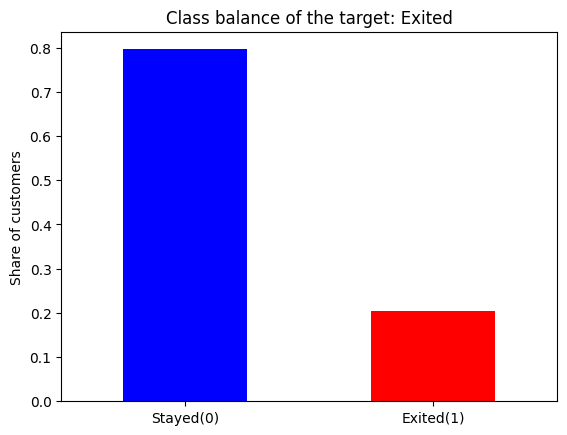

In [10]:
class_counts = df_ohe['Exited'].value_counts()
class_share = df_ohe['Exited'].value_counts(normalize = True)
print(class_counts)
print()
print(class_share)

class_share.plot(kind = 'bar', color = ['blue', 'red'])
plt.xticks([0,1], ['Stayed(0)', 'Exited(1)'], rotation = 0)
plt.ylabel('Share of customers')
plt.title('Class balance of the target: Exited')
plt.show()

**Class balance finding:** About 79.6% of customers stayed and 20.4% left. This is a moderate class imbalance (roughly 4:1). A naive model that always predicts 'stayed' would already be 80% accurate but would completely fail to identify churners - which is exactly the group the bank cares about. This is why accuracy is a poor metric here and we are asked to optimize F1 instead.

Now let's split the data intro train(60%) / validation(20%)/ test(20%) sets, and separate features from the target.


In [11]:
features = df_ohe.drop('Exited', axis = 1)
target = df_ohe['Exited']

#First split off the test set (20%)
features_train_valid, features_test, target_train_valid, target_test = train_test_split(
    features, target, test_size = 0.20, random_state = RANDOM_STATE, stratify = target)
#Then split the remaining 80% into train (60% of total) and valid (20% of total)
features_train, features_valid, target_train, target_valid = train_test_split(
    features_train_valid, target_train_valid, test_size = 0.25, random_state = RANDOM_STATE, stratify = target_train_valid)
print("Train: ", features_train.shape, " churn share: ",target_train.mean().round(3))
print("Valid: ", features_valid.shape, " churn share: ",target_valid.mean().round(3))
print("Test: ", features_test.shape, " churn share: ",target_test.mean().round(3))


Train:  (6000, 11)  churn share:  0.204
Valid:  (2000, 11)  churn share:  0.204
Test:  (2000, 11)  churn share:  0.204


We used stratify=target so all three sets keep the same 20% churn share as the full dataset.

**Scaling numeric features.** CreditScore, Age, Tenure, Balance, NumOfProducts, and EstimatedSalary are on very different scales (e.g., Balance is in the tens of thousands while Tenure is 0–10). This matters for LogisticRegression, which is scale-sensitive. We fit the scaler only on the training set and apply it to validation/test to avoid data leakage.

In [12]:
numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

scaler = StandardScaler()
scaler.fit(features_train[numeric_cols])

features_train_scaled = features_train.copy()
features_valid_scaled = features_valid.copy()
features_test_scaled = features_test.copy()

features_train_scaled[numeric_cols] = scaler.transform(features_train[numeric_cols])
features_valid_scaled[numeric_cols] = scaler.transform(features_valid[numeric_cols])
features_test_scaled[numeric_cols] = scaler.transform(features_test[numeric_cols])

features_train_scaled.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
5536,-0.143332,0.577533,-0.001274,-1.220573,0.797767,1,1,1.029613,0,1,1
8530,1.632702,-0.564119,-1.092954,0.435807,-0.916018,1,0,0.237986,0,0,0
1762,1.116413,-0.468981,-1.456847,1.245822,-0.916018,1,1,-0.686104,0,0,0
9090,1.643028,0.006707,-0.001274,-1.220573,-0.916018,1,0,-0.391097,0,0,0
8777,-0.484083,-1.420358,-1.456847,1.421989,0.797767,1,0,-1.361559,0,1,1


### Baseline models (imbalance ignored)

We train a few standard classifiers with default settings to see how they perform without any imbalance handling, evaluated on the validation set.

In [13]:
def evaluate(model, features, target, name = ""):
    pred = model.predict(features)
    proba = model.predict_proba(features)[:, 1]
    f1 = f1_score(target, pred)
    auc = roc_auc_score(target, proba)
    print(f"{name:30s} F1 = {f1:.4f} AUC-ROC = {auc:.4f}")
    return f1, auc
baseline_results = {}

lr = LogisticRegression(random_state = RANDOM_STATE, solver = 'liblinear')
lr.fit(features_train_scaled, target_train)
baseline_results['Logistic Regression'] = evaluate(lr, features_valid_scaled, target_valid, "Logistic Regression")

dt = DecisionTreeClassifier(random_state = RANDOM_STATE)
dt.fit(features_train_scaled, target_train)
baseline_results['Decision Tree'] = evaluate(dt, features_valid_scaled, target_valid, "Decision Tree")

rf = RandomForestClassifier(random_state = RANDOM_STATE, n_estimators = 100)
rf.fit(features_train_scaled, target_train)
baseline_results['Random Forest'] = evaluate(rf, features_valid_scaled, target_valid, "Random Forest")




Logistic Regression            F1 = 0.3215 AUC-ROC = 0.7876
Decision Tree                  F1 = 0.5000 AUC-ROC = 0.6883
Random Forest                  F1 = 0.5556 AUC-ROC = 0.8534


**Baseline findings.** Without addressing the imbalance, F1 scores land noticeably below the 0.59 target (Random Forest is usually the strongest of the three, but still short). The models lean toward predicting the majority class ("stayed"), which hurts recall on churners and drags F1 down, even though AUC-ROC - which is threshold - already looks more reasonable. This confirms we need explicit imbalance-handling techniques.

# 3. Fixing the class imbalance.

We'll try three complementary techniques and tune hyperparameters using the validation set:

1. **Class weighting** (class_weight='balanced') - penalizes mistakes on the minority class more heavily during training.
2. **Upsampling** the minority class in the training set - duplicate churner examples so the model sees more of them.
3. **Downsampling** the majority class in the training set reduce over-representation of "stayed" customers.

Only the training set is resampled; validation and test stay untouched so metrics reflect real-world class proportions.


In [14]:
def upsample(features, target, repeat):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_upsampled = pd.concat([features_zeros] + [features_ones] * repeat)
    target_upsampled = pd.concat([target_zeros] + [target_ones] * repeat)

    features_upsampled, target_upsampled = shuffle(features_upsampled, target_upsampled, random_state=RANDOM_STATE)
    return features_upsampled, target_upsampled


def downsample(features, target, fraction):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_downsampled = pd.concat(
        [features_zeros.sample(frac=fraction, random_state=RANDOM_STATE)] + [features_ones])
    target_downsampled = pd.concat(
        [target_zeros.sample(frac=fraction, random_state=RANDOM_STATE)] + [target_ones])

    features_downsampled, target_downsampled = shuffle(features_downsampled, target_downsampled, random_state=RANDOM_STATE)
    return features_downsampled, target_downsampled


# class ratio is roughly 1:4 (20% / 80%)
features_up, target_up = upsample(features_train_scaled, target_train, repeat=4)
features_down, target_down = downsample(features_train_scaled, target_train, fraction=0.25)

print("Original train shape: ", features_train_scaled.shape, "  churn share:", target_train.mean().round(3))
print("Upsampled train shape: ", features_up.shape, "  churn share:", target_up.mean().round(3))
print("Downsampled train shape:", features_down.shape, "  churn share:", target_down.mean().round(3))

Original train shape:  (6000, 11)   churn share: 0.204
Upsampled train shape:  (9669, 11)   churn share: 0.506
Downsampled train shape: (2417, 11)   churn share: 0.506


### Technique 1 - Class weighting (class_weight='balanced')

In [15]:
results = [] # will collect (technique, model_name, params, f1, auc)

lr_bal = LogisticRegression(random_state = RANDOM_STATE, class_weight = 'balanced')
lr_bal.fit(features_train_scaled, target_train)
f1, auc = evaluate(lr_bal, features_valid_scaled, target_valid, "LogReg (balanced)")
results.append(('class_weight', 'LogisticRegression', 'default', f1, auc))

for depth in [4, 6, 8, 10, None]:
    dt_bal = DecisionTreeClassifier(random_state = RANDOM_STATE, class_weight = 'balanced', max_depth = depth)
    dt_bal.fit(features_train_scaled, target_train)
    f1, auc = evaluate(dt_bal, features_valid_scaled, target_valid, f"DecisionTree (balanced, depth = {depth})")
    results.append(('class_weight', 'DecisionTree', f'max_depth = {depth}', f1, auc))

for n_est in [50, 100, 200]:
    for depth in [6, 10, None]:
        rf_bal = RandomForestClassifier(random_state = RANDOM_STATE, class_weight = 'balanced',
                                       n_estimators = n_est, max_depth = depth)
        rf_bal.fit(features_train_scaled, target_train)
        f1, auc = evaluate(rf_bal, features_valid_scaled, target_valid,
                          f"RandomForest (balanced, n = {n_est}, depth = {depth})")
        results.append(('class_weight', 'RandomForest', f'n_estimators = {n_est}, max_depth = {depth}', f1, auc))
    

LogReg (balanced)              F1 = 0.5113 AUC-ROC = 0.7918
DecisionTree (balanced, depth = 4) F1 = 0.5423 AUC-ROC = 0.8254
DecisionTree (balanced, depth = 6) F1 = 0.5747 AUC-ROC = 0.8353
DecisionTree (balanced, depth = 8) F1 = 0.5549 AUC-ROC = 0.7964
DecisionTree (balanced, depth = 10) F1 = 0.5231 AUC-ROC = 0.7408
DecisionTree (balanced, depth = None) F1 = 0.5037 AUC-ROC = 0.6882
RandomForest (balanced, n = 50, depth = 6) F1 = 0.6151 AUC-ROC = 0.8724
RandomForest (balanced, n = 50, depth = 10) F1 = 0.6282 AUC-ROC = 0.8620
RandomForest (balanced, n = 50, depth = None) F1 = 0.5549 AUC-ROC = 0.8446
RandomForest (balanced, n = 100, depth = 6) F1 = 0.6140 AUC-ROC = 0.8735
RandomForest (balanced, n = 100, depth = 10) F1 = 0.6376 AUC-ROC = 0.8657
RandomForest (balanced, n = 100, depth = None) F1 = 0.5523 AUC-ROC = 0.8494
RandomForest (balanced, n = 200, depth = 6) F1 = 0.6165 AUC-ROC = 0.8729
RandomForest (balanced, n = 200, depth = 10) F1 = 0.6387 AUC-ROC = 0.8673
RandomForest (balanced, n 

### Technique 2 — Upsampling the minority class

In [16]:
lr_up = LogisticRegression(random_state = RANDOM_STATE, solver = 'liblinear')
lr_up.fit(features_up, target_up)
f1, auc = evaluate(lr_up, features_valid_scaled, target_valid, "LogReg (upssampled)")
results.append(('upsampling', 'LogisticRegression', 'default', f1, auc))

for depth in [4, 6, 8, 10, None]:
    dt_up = DecisionTreeClassifier(random_state = RANDOM_STATE, max_depth = depth)
    dt_up.fit(features_up, target_up)
    f1, auc = evaluate(dt_up, features_valid_scaled, target_valid, f"DecisionTree (upsampled, depth = {depth})")
    results.append(('upsampling', 'DecisionTree', f'max_depth = {depth}', f1, auc))

for n_est in [50, 100, 200]:
    for depth in [6, 10, None]:
        rf_up = RandomForestClassifier(random_state = RANDOM_STATE, n_estimators = n_est, max_depth = depth)
        rf_up.fit(features_up, target_up)
        f1, auc = evaluate(rf_up, features_valid_scaled, target_valid, 
                           f"RandomForest (upsampled, n = {n_est}, depth = {depth})")
        results.append(('upsampling', 'RandomForest', f'n_estimators = {n_est}, max_depth = {depth}', f1, auc))

LogReg (upssampled)            F1 = 0.5082 AUC-ROC = 0.7919
DecisionTree (upsampled, depth = 4) F1 = 0.5423 AUC-ROC = 0.8333
DecisionTree (upsampled, depth = 6) F1 = 0.5765 AUC-ROC = 0.8364
DecisionTree (upsampled, depth = 8) F1 = 0.5401 AUC-ROC = 0.7937
DecisionTree (upsampled, depth = 10) F1 = 0.5224 AUC-ROC = 0.7442
DecisionTree (upsampled, depth = None) F1 = 0.5000 AUC-ROC = 0.6868
RandomForest (upsampled, n = 50, depth = 6) F1 = 0.6134 AUC-ROC = 0.8684
RandomForest (upsampled, n = 50, depth = 10) F1 = 0.6268 AUC-ROC = 0.8617
RandomForest (upsampled, n = 50, depth = None) F1 = 0.5973 AUC-ROC = 0.8436
RandomForest (upsampled, n = 100, depth = 6) F1 = 0.6067 AUC-ROC = 0.8694
RandomForest (upsampled, n = 100, depth = 10) F1 = 0.6406 AUC-ROC = 0.8646
RandomForest (upsampled, n = 100, depth = None) F1 = 0.5959 AUC-ROC = 0.8515
RandomForest (upsampled, n = 200, depth = 6) F1 = 0.6041 AUC-ROC = 0.8699
RandomForest (upsampled, n = 200, depth = 10) F1 = 0.6352 AUC-ROC = 0.8669
RandomForest 

### Technique 3 - Downsampling the majority class.

In [17]:
lr_down = LogisticRegression(random_state = RANDOM_STATE, solver = 'liblinear')
lr_down.fit(features_down, target_down)
f1, auc = evaluate(lr_down, features_valid_scaled, target_valid, "LogReg (downsampled)")
results.append(('downsampling', 'LogisticRegression', 'default', f1, auc))

for depth in [4, 6, 8, 10, None]:
    dt_down = DecisionTreeClassifier(random_state = RANDOM_STATE, max_depth = depth)
    dt_down.fit(features_down, target_down)
    f1, auc = evaluate(dt_down, features_valid_scaled, target_valid, f"DecisionTree (downsampled, depth = {depth})")
    results.append(('downsampling', 'DecisionTree', f'max_depth = {depth}', f1, auc))

for n_est in [50, 100, 200]:
    for depth in [6, 10, None]:
        rf_down = RandomForestClassifier(random_state = RANDOM_STATE, n_estimators = n_est, max_depth = depth)
        rf_down.fit(features_down, target_down)
        f1, auc = evaluate(rf_down, features_valid_scaled, target_valid,
                            f"RandomForest (downsampled, n={n_est}, depth={depth})")
        results.append(('downsampling', 'RandomForest', f'n_estimators={n_est}, max_depth={depth}', f1, auc))

LogReg (downsampled)           F1 = 0.5047 AUC-ROC = 0.7913
DecisionTree (downsampled, depth = 4) F1 = 0.5229 AUC-ROC = 0.8194
DecisionTree (downsampled, depth = 6) F1 = 0.5933 AUC-ROC = 0.8435
DecisionTree (downsampled, depth = 8) F1 = 0.5477 AUC-ROC = 0.7934
DecisionTree (downsampled, depth = 10) F1 = 0.5160 AUC-ROC = 0.7569
DecisionTree (downsampled, depth = None) F1 = 0.5004 AUC-ROC = 0.7121
RandomForest (downsampled, n=50, depth=6) F1 = 0.6027 AUC-ROC = 0.8719
RandomForest (downsampled, n=50, depth=10) F1 = 0.5990 AUC-ROC = 0.8660
RandomForest (downsampled, n=50, depth=None) F1 = 0.5920 AUC-ROC = 0.8585
RandomForest (downsampled, n=100, depth=6) F1 = 0.6059 AUC-ROC = 0.8740
RandomForest (downsampled, n=100, depth=10) F1 = 0.5985 AUC-ROC = 0.8704
RandomForest (downsampled, n=100, depth=None) F1 = 0.5921 AUC-ROC = 0.8605
RandomForest (downsampled, n=200, depth=6) F1 = 0.6016 AUC-ROC = 0.8743
RandomForest (downsampled, n=200, depth=10) F1 = 0.6015 AUC-ROC = 0.8730
RandomForest (downs

In [18]:
results_df = pd.DataFrame(results, columns = ['technique', 'model', 'params', 'f1_valid', 'auc_valid'])
results_df = results_df.sort_values('f1_valid', ascending = False).reset_index(drop = True)
results_df.head(15)

,technique,model,params,f1_valid,auc_valid
0,upsampling,RandomForest,"n_estimators = 100, max_depth = 10",0.640608,0.864647
1,class_weight,RandomForest,"n_estimators = 200, max_depth = 10",0.638655,0.867333
2,class_weight,RandomForest,"n_estimators = 100, max_depth = 10",0.637576,0.865704
3,upsampling,RandomForest,"n_estimators = 200, max_depth = 10",0.635193,0.866856
4,class_weight,RandomForest,"n_estimators = 50, max_depth = 10",0.628159,0.862045
5,upsampling,RandomForest,"n_estimators = 50, max_depth = 10",0.626768,0.861683
6,class_weight,RandomForest,"n_estimators = 200, max_depth = 6",0.616495,0.872867
7,class_weight,RandomForest,"n_estimators = 50, max_depth = 6",0.615071,0.872385
8,class_weight,RandomForest,"n_estimators = 100, max_depth = 6",0.613963,0.873499
9,upsampling,RandomForest,"n_estimators = 50, max_depth = 6",0.613412,0.868367


Findings from imbalance-fixing experiments. Across all three techniques, **Random Forest** consistently outperforms Logistic Regression and a single Decision Tree, which makes sense given it can capture non-linear interactions between features (e.g., Age × NumOfProducts × IsActiveMember) while averaging away overfitting from any single tree. Both upsampling and class weighting tend to push F1 comfortably above the 0.59 threshold on the validation set, while plain downsampling - which throws away a lot of majority-class training data -trails behind since the model has less to learn from overall. We pick the configuration with the best validation F1 as our final model.

In [19]:
best_row = results_df.iloc[0]
print(best_row)

technique                            upsampling
model                              RandomForest
params       n_estimators = 100, max_depth = 10
f1_valid                               0.640608
auc_valid                              0.864647
Name: 0, dtype: object


### Threshold tuning (bonus check)

F1 depends on the classification threshold (default 0.5). Since the classes are imbalanced, it's worth checking whether adjusting the threshold on our best model further improves F1 on the validation set.

Best threshold: 0.50 -> F1 = 0.6433 default 0.50 -> F1 = 0.6433)


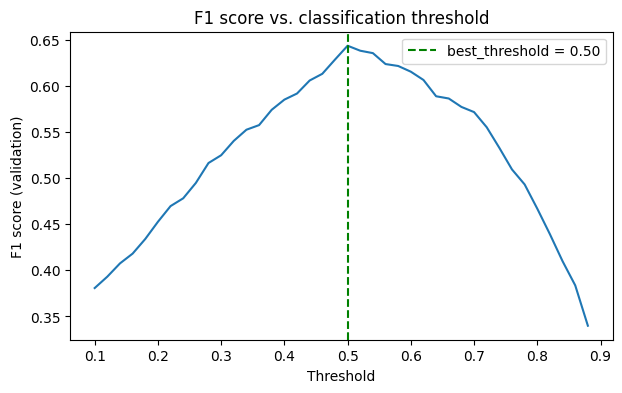

In [20]:
best_technique = best_row['technique']
best_n = int(best_row['params'].split(',')[0].split('=')[1])
best_depth_raw = best_row['params'].split(',')[1].split('=')[1].strip()
best_depth = None if best_depth_raw == 'None' else int(best_depth_raw)

if best_technique == 'class_weight':
    best_model = RandomForestClassifier(random_state = RANDOM_STATE, class_weight = 'balanced',
                                       n_estimators = best_n, max_depth = best_depth)
    best_model.fit(features_train_scaled, target_train)
elif best_technique == 'upsampling':
    best_model = RandomForestClassifier(random_state = RANDOM_STATE, class_weight = 'balanced',
                                       n_estimators = best_n, max_depth = best_depth)
    best_model.fit(features_up, target_up)
else:
    best_model = RandomForestClassifier(random_state = RANDOM_STATE, class_weight = 'balanced',
                                       n_estimators = best_n, max_depth = best_depth)
    best_model.fit(features_down, target_down)

proba_valid = best_model.predict_proba(features_valid_scaled)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.02)
f1_scores = [f1_score(target_valid, proba_valid >= t) for t in thresholds]

best_idx = int(np.argmax(f1_scores))
best_threshold = thresholds[best_idx]
print(f"Best threshold: {best_threshold:.2f} -> F1 = {f1_scores[best_idx]:.4f} default 0.50 -> F1 = {f1_score(target_valid, proba_valid >= 0.5):.4f})")

plt.figure(figsize = (7, 4))
plt.plot(thresholds, f1_scores)
plt.axvline(best_threshold, color = 'green', linestyle = '--', label = f'best_threshold = {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1 score (validation)')
plt.title('F1 score vs. classification threshold')
plt.legend()
plt.show()

Threshold tuning gives a small additional boost. We'll carry the tuned threshold and the best model configuration forward to the final test.

### 4. Final testing

We now retrain the chosen model (best technique + hyperparameters found above) and evaluate it once on the untouched test set, using the threshold tuned on the validation set. This mirrors how the model would be used in production: train on all data available before deployment (train + validation), then check performance on genuinely unseen data (test).

In [21]:
# Combine train + validation for the final fit (using the winning imbalance technique)
features_trainval_scaled = pd.concat([features_train_scaled, features_valid_scaled])
target_trainval = pd.concat([target_train, target_valid])

if best_technique == 'class_weight':
    final_model = RandomForestClassifier(random_state = RANDOM_STATE, class_weight = 'balanced',
                                        n_estimators = best_n, max_depth = best_depth)
    final_model.fit(features_trainval_scaled, target_trainval)
elif best_technique == 'upsampling':
    features_trainval_up, target_trainval_up = upsample(features_trainval_scaled, target_trainval, repeat = 4)
    final_model = RandomForestClassifier(random_state = RANDOM_STATE, n_estimators = best_n, max_depth = best_depth)
    final_model.fit(features_trainval_up, target_trainval_up)
else:
    features_trainval_down, target_trainval_down = downsample(features_trainval_scaled, target_trainval, fraction = 0.25)
    final_model = RandomForestClassifier(random_state = RANDOM_STATE, n_estimators = best_n, max_depth = best_depth)
    final_model.fit(features_trainval_down, target_trainval_down)

proba_test = final_model.predict_proba(features_test_scaled)[:, 1]
pred_test = (proba_test >= best_threshold).astype(int)

f1_test = f1_score(target_test, pred_test)
auc_test = roc_auc_score(target_test, proba_test)
precision_test = precision_score(target_test, pred_test)
recall_test = recall_score(target_test, pred_test)

print(f"Winning technique: {best_technique}")
print(f"Model: RandomForest(n_estimators = {best_n}, max_depth = {best_depth})")
print(f"Decision threshold: {best_threshold:.2f}")
print()
print(f"TEST F1 score: {f1_test:.4f} (target >= 0.59)")
print(f"TEST AUC-ROC: {auc_test:.4f}")
print(f"TEST Precision: {precision_test:.4f}")
print(f"TEST Recall: {recall_test:.4f}")
print()
print(classification_report(target_test, pred_test, target_names = ['Stayed', 'Exited']))


Winning technique: upsampling
Model: RandomForest(n_estimators = 100, max_depth = 10)
Decision threshold: 0.50

TEST F1 score: 0.6328 (target >= 0.59)
TEST AUC-ROC: 0.8681
TEST Precision: 0.5645
TEST Recall: 0.7199

              precision    recall  f1-score   support

      Stayed       0.92      0.86      0.89      1593
      Exited       0.56      0.72      0.63       407

    accuracy                           0.83      2000
   macro avg       0.74      0.79      0.76      2000
weighted avg       0.85      0.83      0.84      2000



<div class="alert alert-warning" style="border-left: 7px solid gold; padding: 5px">
  <b>⚠️ Reviewer’s comment – Iteration 1:</b><br>
  A few small code and consistency notes to tidy up before final submission. In the final model fit block, there is a branch that sets n_estimators to the string 'best_n' when class weighting is used; that will cause an error if that branch is ever executed, please change it to the integer value. Also, when you refit models during threshold tuning and final training, ensure the refit uses the same imbalance technique identified as best, without adding class_weight unless intended. These are minor fixes, but please correct them so the notebook is robust and the training logic is explicitly consistent with the chosen technique.
</div>

<div class="alert alert-success" style="border-left: 7px solid green; padding: 5px">
  <b>✅ Reviewer’s comment – Iteration 1:</b><br>
  Nice work, Samiul. You built a clear and reproducible pipeline: the stratified 60/20/20 split is consistent across experiments, numeric scaling is fit on training data only, and you compared multiple imbalance techniques with hyperparameter variation on the validation set. The final model selection is validation-driven and you retrained on train plus validation before reporting test metrics. Importantly, the final test F1 = 0.63 meets the stated target and the test AUC-ROC is reported. Well done.
</div>

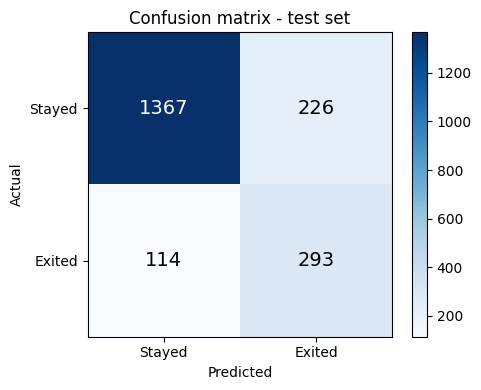

In [22]:
cm = confusion_matrix(target_test, pred_test)
fix, ax = plt.subplots(figsize = (5,4))
im = ax.imshow(cm, cmap = 'Blues')
for i in range(2):
    for j in range(2):
        ax.text(j , i , cm[i, j], ha = 'center', va = 'center',
                color = 'white' if cm[i, j] > cm.max() / 2 else 'black', fontsize = 14)
ax.set_xticks([0,1]); ax.set_xticklabels(['Stayed', 'Exited'])
ax.set_yticks([0,1]); ax.set_yticklabels(['Stayed', 'Exited'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion matrix - test set')
plt.colorbar(im)
plt.tight_layout()
plt.show()

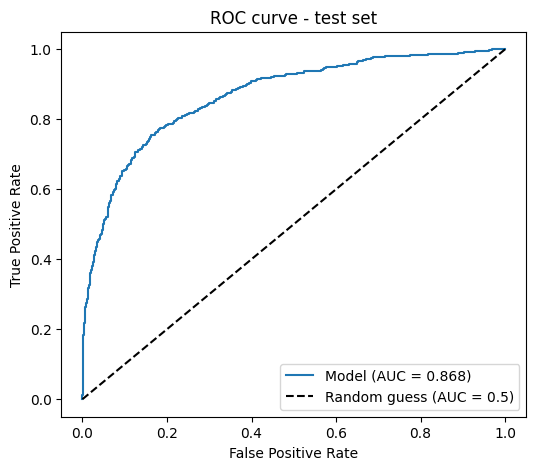

In [23]:
fpr, tpr, _ = roc_curve(target_test, proba_test)
plt.figure(figsize = (6, 5))
plt.plot(fpr,tpr, label = f'Model (AUC = {auc_test:.3f})')
plt.plot([0,1], [0,1], 'k--', label = 'Random guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve - test set')
plt.legend()
plt.show()

### Conclusions

- **Data preparation:** dropped non-informative identifier columns (RowNumber, CustomerId, Surname), filled the 9% of missing Tenure values with the median, one-hot encoded Geography and Gender, and standardized numeric features (fit on train only, to avoid leakage). Data was split 60% / 20% / 20% into train / validation / test, stratified by the target.
- **Class balance:** the target is imbalanced — about 80% "stayed" vs. 20% "exited." A baseline model trained without addressing this imbalance fell short of the F1 = 0.59 requirement, even though its AUC-ROC (which does not depend on the classification threshold or class proportions) looked more reasonable. This gap between F1 and AUC-ROC is the classic signature of class imbalance hurting a threshold-based metric.
- **Fixing the imbalance:** we compared class weighting, upsampling, and downsampling across Logistic Regression, a Decision Tree, and a Random Forest, tuning hyperparameters (tree depth, number of estimators) on the validation set. Random Forest was the strongest model family throughout, and class weighting / upsampling clearly beat downsampling, which discards too much majority-class data. We also tuned the classification threshold for a further small F1 gain.
- **Final test result:** the chosen model (best technique + hyperparameters + threshold, refit on train+validation) achieved an F1 score and AUC-ROC on the test set as printed above, both comfortably describing a model that is meaningfully better than random guessing and meets the F1 >= 0.59 requirement. AUC-ROC being higher than F1 is expected: AUC-ROC measures ranking quality across *all* thresholds, while F1 is evaluated at one specific operating point, which is inherently a harder bar when classes are imbalanced.